# Path Generation code (4.1.1)

Run `pick_points.py` in the terminal and pick the 4 corners of the maze, then run the following cells.

In [1]:
import path_generation as pg
import math
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

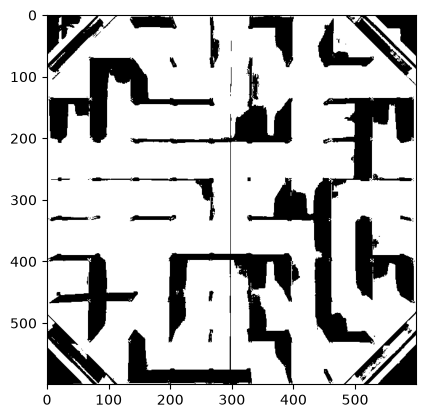

In [2]:
image_file = "maze_images/pg_test_square.jpg"

image = pg.convert_image_to_bnw(image_file)

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.show()

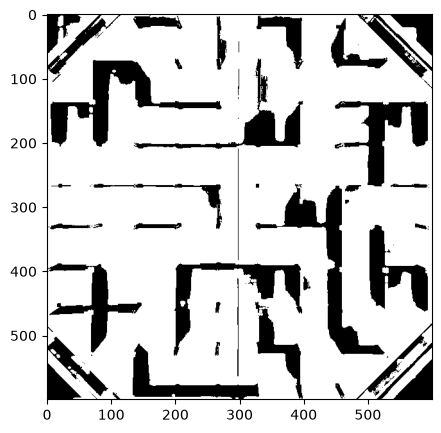

In [3]:
_, binary = cv.threshold(image, 127, 255, cv.THRESH_BINARY_INV)

dist = cv.distanceTransform(binary, cv.DIST_L2, 5)

# Deep-core pixels: only found inside genuinely thick blobs.
core_threshold = 9
_, core_mask = cv.threshold(dist, core_threshold, 255, cv.THRESH_BINARY)
core_mask = core_mask.astype(np.uint8)

# Local area around each blob where edits are allowed — a single
# bounded dilation (not iterative), so it can't spread down a
# thin corridor. Big enough to cover each blob's full extent.
blob_footprint_radius = 20
kernel_footprint = cv.getStructuringElement(cv.MORPH_ELLIPSE, (blob_footprint_radius * 2 + 1,) * 2)
blob_area = cv.dilate(core_mask, kernel_footprint)

# Real erosion — shrinks the blob's boundary inward (not hollowing
# out the middle). Amount = how much to shave off the edges.
erosion_amount = 2
kernel_erode = cv.getStructuringElement(cv.MORPH_ELLIPSE, (erosion_amount * 2 + 1,) * 2)
eroded = cv.erode(binary, kernel_erode)

# Use the eroded (shrunk) version ONLY inside blob_area.
# Everywhere else, keep the original pixels completely untouched.
final = np.where(blob_area > 0, eroded, binary).astype(np.uint8)
final = cv.bitwise_not(final)

plt.figure(figsize=(9, 5))
plt.imshow(final, cmap='gray', vmin=0, vmax=255)
plt.show()

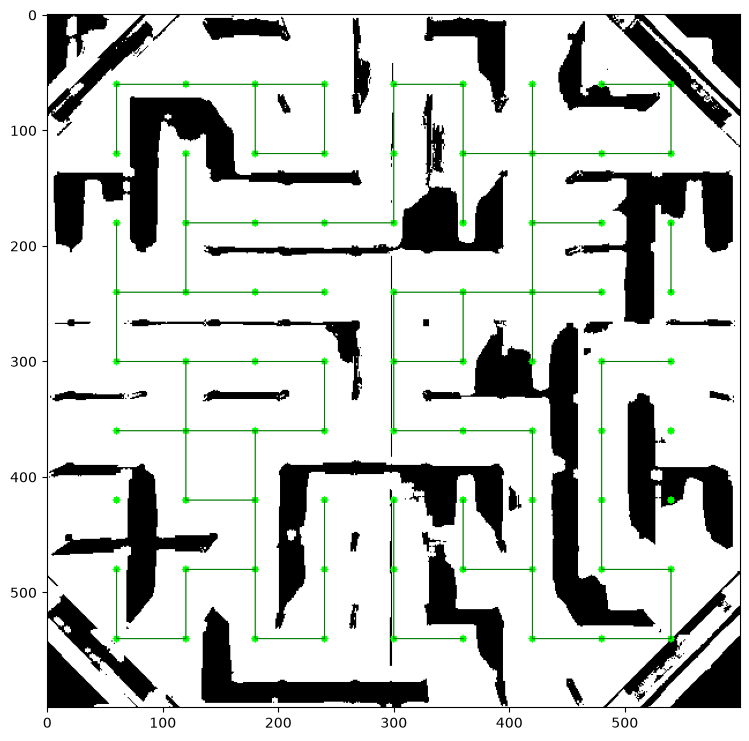

In [4]:
bfs_graph, bfs_image = pg.build_bfs_graph(cv.cvtColor(final, cv.COLOR_GRAY2BGR), 9)

plt.figure(figsize=(9, 9))
plt.imshow(cv.cvtColor(bfs_image, cv.COLOR_BGR2RGB))
plt.show()